In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize

from matplotlib import colors

from cmcrameri import cm as cmcra



matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=128):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

lipari_cut = truncate_colormap(cmcra.lipari, minval=0.15, maxval=1.0, n=128)

In [3]:
inputs = xr.open_dataset("../model_input_dataset.nc")

index2name = {10: "Ross",
              11: "Filchner-Ronne",
              31: "Amery",
              52: "Dotson",
              66: "Pine Island",
              43: "Riiser-Larsen",
              48: "Totten",
              45: "Baudouin",
              33: "Moscow Univ."
             }

In [71]:
Ap_forcing_winter = inputs.sel(Nisf=31).Ap.values

Ap_grp_year_winter = [Ap_forcing_winter[i:i+8] for i in range(0, len(Ap_forcing_winter), 8)]

Ap_grp_year = []

for array in Ap_grp_year_winter:
    Ap_grp_year.append(np.pad(array, (2, 2), mode='constant', constant_values=0))

Ap_grp_year = np.array(Ap_grp_year)
Ap_seasonnality = np.mean(Ap_grp_year,axis=0)
Ap_forcing = np.ravel(Ap_grp_year)
Ap_forcing = Ap_forcing+1e7 # Ensure no 0 values

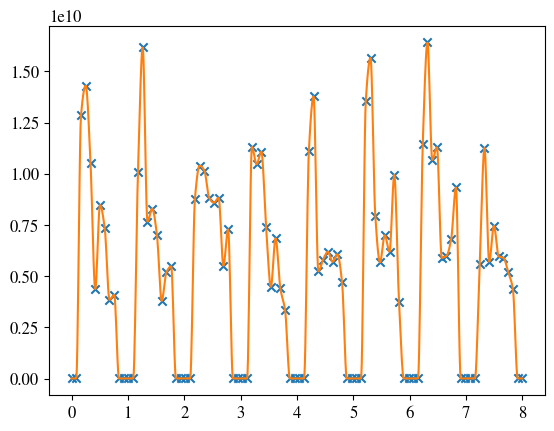

In [72]:
from scipy.interpolate import make_interp_spline
from scipy.interpolate import PchipInterpolator

x_month = np.linspace(0,8,12*8)
x_goal = np.linspace(0,8,1000)

#spline = make_interp_spline(x_month, Ap_forcing, k=3, bc_type='periodic')
#y_new = spline(x_goal)

interp = PchipInterpolator(x_month, Ap_forcing)
y_new = interp(x_goal)

plt.scatter(x_month,Ap_forcing,marker='x')
plt.plot(x_goal,y_new,c='tab:orange')

In [ ]:
def two_cavity_box(t,z):
    Tp, Td, Tc1, Tc2, Sp, Sd, Sc1, Sc2 = z
    
    sigma = compute_sigma(Tp, Sp, Td, Sd)
    kappa = compute_kappa_step(sigma)
    Tb1 = compute_Tb_2eq(Sc1,H1)
    Tb2 = compute_Tb_2eq(Sc2,H2)
    Ts = compute_Ts_2eq(Sp)
    Fs = compute_Fs(Sp,Omega)
    
    return [1/Vp*(q*(Tc3-Tp)-kappa*surf_p*(Tp-Td)-gammaT*surf_p*(Tp-Ts)),
            1/Vd*(q*(T0-Td)+kappa*surf_p*(Tp-Td)),
            1/Vc1*(q*(Td-Tc1)-gammaT*surf_c*(Tc1-Tb1)),
            1/Vc2*(q*(Tc1-Tc2)-gammaT*surf_c*(Tc2-Tb2)),
            1/Vp*(q*(Sc3-Sp)-kappa*surf_p*(Sp-Sd)+surf_p/rho_star*Fs),
            1/Vd*(q*(S0-Sd)+kappa*surf_p*(Sp-Sd)),
            1/Vc1*(q*(Sd-Sc1)-gammaT*surf_c*Sstar/lamb*(Tc1-Tb1)),
            1/Vc2*(q*(Sc1-Sc2)-gammaT*surf_c*Sstar/lamb*(Tc2-Tb2))